# Modelo alternativo / benchmark: Regresión Log-Log con Ridge




In [1]:
# 1. Librerías
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import joblib

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)


## 2. Carga de datos



In [2]:
# 2. Carga de datos
LOCAL_MASTER = Path('df_master_precios_dinamicos.csv')
BASE_URL = 'https://raw.githubusercontent.com/Carlos2935/Proyecto_aplicado/master/'

if LOCAL_MASTER.exists():
    print('Cargando tabla maestra local...')
    df_modelo = pd.read_csv(LOCAL_MASTER)
    if 'fecha' in df_modelo.columns:
        df_modelo['fecha'] = pd.to_datetime(df_modelo['fecha'], errors='coerce')
else:
    print('Reconstruyendo tabla maestra desde GitHub...')
    eventos = pd.read_parquet(BASE_URL + 'eventos.parquet')
    productos = pd.read_parquet(BASE_URL + 'productos.parquet')
    bodegas = pd.read_parquet(BASE_URL + 'bodegas.parquet')
    stock = pd.read_parquet(BASE_URL + 'stock.parquet')

    eventos['fecha'] = pd.to_datetime(eventos['fecha'], errors='coerce')
    ventas = eventos[eventos['tipo_evento'] == 'venta'].copy()

    ventas_diarias = ventas.groupby(['fecha', 'id_producto', 'id_bodega'], as_index=False).agg(
        cantidad_vendida=('cantidad', 'sum'),
        ingreso_total=('precio_total', 'sum')
    )

    ventas_diarias['precio_promedio'] = ventas_diarias['ingreso_total'] / ventas_diarias['cantidad_vendida']

    df_modelo = ventas_diarias.merge(productos, on='id_producto', how='left')
    df_modelo = df_modelo.merge(bodegas, on='id_bodega', how='left')

    stock_clean = stock[['id_producto', 'id_bodega', 'cantidad']].rename(columns={'cantidad': 'stock_actual'})
    df_modelo = df_modelo.merge(stock_clean, on=['id_producto', 'id_bodega'], how='left')
    df_modelo['stock_actual'] = df_modelo['stock_actual'].fillna(0)

print('Filas cargadas:', len(df_modelo))
df_modelo.head()


Reconstruyendo tabla maestra desde GitHub...
Filas cargadas: 1808442


,fecha,id_producto,id_bodega,cantidad_vendida,ingreso_total,precio_promedio,desc_producto,talla,color,marca,genero,categoria,subcategoria,patron,largo,temporada,tipo_x,material,ciudad,nombre_bodega,tipo_y,region,pais,antiguedad_dias,stock_actual
0,2024-08-30,PROD_000017,STORE_000057,1,119900.00,119900.00,PROD_DESC_000018,36,NC,BRAND_000014,MASCULINO,CORREA,REATA,UNICOLOR,NO APLICA,2024-2 (COMPRA Jul 01 - Sep 30),TYPE_000096,ACCESORIOS,CITY_000006,None,STORE_TYPE_000001,STORE_DESC_000088,URBAN,57.0,0.0
1,2024-08-30,PROD_000018,STORE_000146,1,119900.00,119900.00,PROD_DESC_000018,30,NG,BRAND_000014,MASCULINO,CORREA,REATA,UNICOLOR,NO APLICA,2024-2 (COMPRA Jul 01 - Sep 30),TYPE_000096,ACCESORIOS,CITY_000014,Multimarca,STORE_TYPE_000010,STORE_DESC_000399,URBAN,111.0,0.0
2,2024-08-30,PROD_000018,STORE_000349,1,113905.00,113905.00,PROD_DESC_000018,30,NG,BRAND_000014,MASCULINO,CORREA,REATA,UNICOLOR,NO APLICA,2024-2 (COMPRA Jul 01 - Sep 30),TYPE_000096,ACCESORIOS,CITY_000005,Multimarca,STORE_TYPE_000010,STORE_DESC_000387,URBAN,141.0,0.0
3,2024-08-30,PROD_000019,STORE_000092,1,98953.47,98953.47,PROD_DESC_000018,32,NG,BRAND_000014,MASCULINO,CORREA,REATA,UNICOLOR,NO APLICA,2024-2 (COMPRA Jul 01 - Sep 30),TYPE_000096,ACCESORIOS,CITY_000022,On Line,STORE_TYPE_000010,STORE_DESC_000390,ON LINE,NaN,0.0
4,2024-08-30,PROD_000019,STORE_000311,1,119900.00,119900.00,PROD_DESC_000018,32,NG,BRAND_000014,MASCULINO,CORREA,REATA,UNICOLOR,NO APLICA,2024-2 (COMPRA Jul 01 - Sep 30),TYPE_000096,ACCESORIOS,CITY_000014,Multimarca,STORE_TYPE_000010,STORE_DESC_000385,URBAN,93.0,0.0


## 3. Preparación simple de variables



In [3]:
# 3. Limpieza básica y variables derivadas
required_cols = ['fecha', 'cantidad_vendida', 'precio_promedio', 'stock_actual']
missing = [c for c in required_cols if c not in df_modelo.columns]
if missing:
    raise ValueError(f'Faltan columnas requeridas: {missing}')

# Filtros mínimos de calidad
df = df_modelo.copy()
df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')
df = df.dropna(subset=['fecha', 'cantidad_vendida', 'precio_promedio'])
df = df[(df['cantidad_vendida'] > 0) & (df['precio_promedio'] > 0)].copy()

# Variables de calendario
df['mes'] = df['fecha'].dt.month
df['dia_semana'] = df['fecha'].dt.dayofweek

# Transformaciones logarítmicas para modelo econométrico simple
df['log_precio'] = np.log(df['precio_promedio'])
df['log_stock'] = np.log1p(df['stock_actual'])
df['log_demanda'] = np.log1p(df['cantidad_vendida'])

# Asegurar que las variables categóricas existan
for col in ['categoria', 'marca', 'region']:
    if col not in df.columns:
        df[col] = 'No disponible'
    df[col] = df[col].fillna('No disponible').astype(str)

# Reducir cardinalidad de marca para que el modelo siga siendo simple
top_marcas = df['marca'].value_counts().head(20).index
df['marca_simple'] = np.where(df['marca'].isin(top_marcas), df['marca'], 'Otras')

print('Filas después de limpieza:', len(df))
print('Rango de fechas:', df['fecha'].min(), 'a', df['fecha'].max())
df[['fecha', 'cantidad_vendida', 'precio_promedio', 'stock_actual', 'categoria', 'marca_simple', 'region']].head()


Filas después de limpieza: 1799552
Rango de fechas: 2024-08-30 00:00:00 a 2026-03-29 00:00:00


,fecha,cantidad_vendida,precio_promedio,stock_actual,categoria,marca_simple,region
0,2024-08-30,1,119900.00,0.0,CORREA,BRAND_000014,STORE_DESC_000088
1,2024-08-30,1,119900.00,0.0,CORREA,BRAND_000014,STORE_DESC_000399
2,2024-08-30,1,113905.00,0.0,CORREA,BRAND_000014,STORE_DESC_000387
3,2024-08-30,1,98953.47,0.0,CORREA,BRAND_000014,STORE_DESC_000390
4,2024-08-30,1,119900.00,0.0,CORREA,BRAND_000014,STORE_DESC_000385


## 4. División temporal train/test



In [4]:
# 4. Train/test temporal
features_num = ['log_precio', 'log_stock', 'mes', 'dia_semana']
features_cat = ['categoria', 'marca_simple', 'region']
target = 'log_demanda'

model_cols = features_num + features_cat + [target, 'fecha', 'cantidad_vendida']
df_model = df.dropna(subset=model_cols).sort_values('fecha').copy()

cutoff_idx = int(len(df_model) * 0.80)
train = df_model.iloc[:cutoff_idx].copy()
test = df_model.iloc[cutoff_idx:].copy()

X_train = train[features_num + features_cat]
y_train = train[target]
X_test = test[features_num + features_cat]
y_test_log = test[target]
y_test_real = test['cantidad_vendida'].values

print('Train:', train.shape)
print('Test:', test.shape)
print('Fecha máxima train:', train['fecha'].max())
print('Fecha mínima test:', test['fecha'].min())


Train: (1439622, 31)
Test: (359906, 31)
Fecha máxima train: 2025-12-11 00:00:00
Fecha mínima test: 2025-12-11 00:00:00


## 5. Entrenamiento del modelo benchmark


In [5]:
# 5. Pipeline de preprocesamiento + modelo
numeric_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=20))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipe, features_num),
    ('cat', categorical_pipe, features_cat)
])

modelo_benchmark = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=10.0, random_state=42))
])

# Limpieza defensiva antes de entrenar
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

modelo_benchmark.fit(X_train, y_train)
print('Modelo benchmark entrenado correctamente.')

Modelo benchmark entrenado correctamente.


## 6. Evaluación


In [6]:
# 6. Métricas de evaluación

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def wmape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.sum(np.abs(y_true))
    return np.nan if denom == 0 else np.sum(np.abs(y_true - y_pred)) / denom

pred_log = modelo_benchmark.predict(X_test)

pred_real = np.expm1(pred_log)
pred_real = np.clip(pred_real, 0, None)

# Asegurar que no haya NaN o infinitos en evaluación
y_eval = np.asarray(y_test_real, dtype=float)
pred_eval = np.asarray(pred_real, dtype=float)

mask = np.isfinite(y_eval) & np.isfinite(pred_eval)
y_eval = y_eval[mask]
pred_eval = pred_eval[mask]

mse = mean_squared_error(y_eval, pred_eval)
rmse = np.sqrt(mse)

metrics = {
    'Modelo': 'Benchmark Ridge Log-Log',
    'R2': r2_score(y_eval, pred_eval),
    'MAE': mean_absolute_error(y_eval, pred_eval),
    'RMSE': rmse,
    'WMAPE': wmape(y_eval, pred_eval)
}

pd.DataFrame([metrics])

,Modelo,R2,MAE,RMSE,WMAPE
0,Benchmark Ridge Log-Log,0.029106,0.039122,0.179572,0.038194


## 7. Comparación visual de predicción vs demanda real




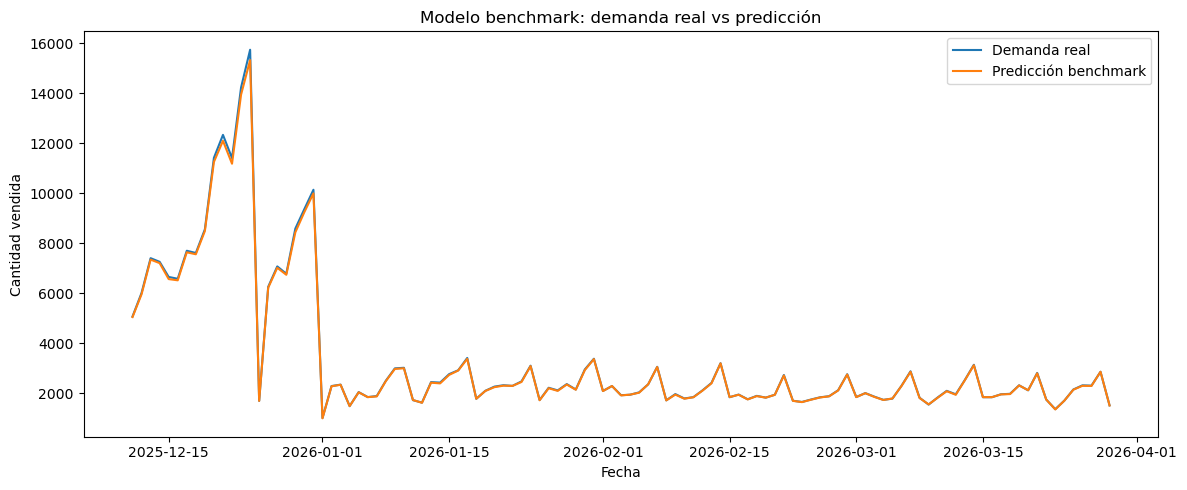

In [7]:
# 7. Gráfica agregada por fecha
resultados = test[['fecha', 'cantidad_vendida']].copy()
resultados['prediccion_benchmark'] = pred_real

serie_eval = resultados.groupby('fecha', as_index=False).agg(
    demanda_real=('cantidad_vendida', 'sum'),
    demanda_predicha=('prediccion_benchmark', 'sum')
)

plt.figure(figsize=(12, 5))
plt.plot(serie_eval['fecha'], serie_eval['demanda_real'], label='Demanda real')
plt.plot(serie_eval['fecha'], serie_eval['demanda_predicha'], label='Predicción benchmark')
plt.title('Modelo benchmark: demanda real vs predicción')
plt.xlabel('Fecha')
plt.ylabel('Cantidad vendida')
plt.legend()
plt.tight_layout()
plt.show()


## 8. Interpretación económica básica: elasticidad




In [8]:
# 8. Extracción aproximada de coeficientes
ridge_model = modelo_benchmark.named_steps['model']
pre = modelo_benchmark.named_steps['preprocessor']

feature_names = pre.get_feature_names_out()
coefs = pd.DataFrame({
    'variable': feature_names,
    'coeficiente': ridge_model.coef_
}).sort_values('coeficiente')

elasticidad_aprox = coefs.loc[coefs['variable'].str.contains('log_precio', regex=False), 'coeficiente']

print('Elasticidad aproximada precio-demanda del benchmark:')
if len(elasticidad_aprox) > 0:
    print(round(float(elasticidad_aprox.iloc[0]), 4))
else:
    print('No encontrada')

coefs.head(10)


Elasticidad aproximada precio-demanda del benchmark:
-0.004


,variable,coeficiente
44,cat__categoria_PAÑOLETA,-0.020991
56,cat__categoria_TARJETERO,-0.018732
59,cat__categoria_TIRAS AUXILIARES,-0.018497
50,cat__categoria_ROPA INTERIOR,-0.017905
28,cat__categoria_FUNDA PC,-0.014216
16,cat__categoria_BUFANDAS Y CORBATAS,-0.013487
48,cat__categoria_PORTA PASAPORTE,-0.013178
60,cat__categoria_TOPS,-0.012696
33,cat__categoria_LEGGINS,-0.012183
51,cat__categoria_ROPA INTERIOR,-0.010998
